# Notebook 02 — Escalado, PCA y selección de variables

Comparamos distintas formas de preparar las entradas para predecir abandono.

Usamos regresión logística como modelo de referencia y evaluamos F1, precisión
y recall mediante validación cruzada por grupos.

El escalado, PCA y la selección se ajustan dentro de cada partición de entrenamiento.
El conjunto de prueba permanece reservado para el notebook 04.

La comparación sirve para elegir una preparación inicial. Sus resultados no
representan todavía el desempeño final del proyecto.

## Configuración

Definimos las rutas de churn. Usamos su entorno Python en local y ajustamos la ubicación de Drive para Colab.

In [1]:
EN_COLAB = False

if EN_COLAB:
    %pip install imbalanced-learn -q

    from google.colab import drive
    drive.mount("/content/drive")
    RUTA_BASE = "/content/drive/MyDrive/churn/"
else:
    RUTA_BASE = "./"

RUTA_DATOS = RUTA_BASE + "data/"
RUTA_MODELOS = RUTA_BASE + "models/"
RUTA_RESULTADOS = RUTA_BASE + "resultados/"
RUTA_FIGURAS = RUTA_BASE + "figuras/"

## Importaciones

Cargamos escaladores, PCA y SelectKBest con ANOVA. Esta versión sigue el flujo de clase, con selección simplificada a ANOVA y regresión logística como única referencia.

In [2]:
import os
import json
import hashlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

for ruta in [RUTA_MODELOS, RUTA_RESULTADOS, RUTA_FIGURAS]:
    os.makedirs(ruta, exist_ok=True)

## Cargar entrenamiento

Leemos entrenamiento y sus grupos. Verificamos que corresponden a las asignaciones
guardadas en el notebook 01.

Los identificadores de fila y grupo no son entradas del modelo.
Conservamos inicialmente las once entradas, incluidas edad y grupo de edad.

In [3]:
train = pd.read_csv(RUTA_DATOS + "train.csv")
datos_grupos = pd.read_csv(RUTA_DATOS + "grupos_train.csv")

with open(RUTA_DATOS + "particion_01.json", encoding="utf-8") as archivo:
    particion = json.load(archivo)

X_train = train.drop(columns="abandono")
y_train = train["abandono"]
grupos_train = datos_grupos["grupo"]

filas_esperadas = []
grupos_esperados = []

for posicion, conjunto in enumerate(particion["asignacion"]):
    if conjunto == "train":
        filas_esperadas.append(posicion)
        grupos_esperados.append(particion["grupos"][posicion])

assert list(X_train.columns) == particion["columnas_entrada"]
assert len(train) == len(datos_grupos) == len(filas_esperadas)
assert datos_grupos["fila_original"].tolist() == filas_esperadas
assert grupos_train.tolist() == grupos_esperados
assert train.isna().sum().sum() == 0

print("Filas de entrenamiento:", len(train))
print("Entradas:", X_train.shape[1])
print("Abandonos:", int(y_train.sum()))
assert set(y_train.unique()) == {0, 1}
assert np.isfinite(X_train.to_numpy()).all()

Filas de entrenamiento: 2511
Entradas: 11
Abandonos: 392


Trabajamos con 2.511 registros, once entradas y 392 abandonos (15,61 %). Los grupos y las filas coinciden con la partición guardada.

## Validación cruzada por grupos

Construimos diez particiones y las reutilizamos en todas las comparaciones.
Los perfiles idénticos permanecen juntos.

F1 de abandono es la métrica principal. También reportamos precisión y recall.
La desviación del F1 muestra cuánto varía entre particiones; no es un intervalo
de confianza.

In [4]:
cv = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

particiones_cv = []

for indices_train, indices_validacion in cv.split(
    X_train, y_train, grupos_train
):
    assert set(grupos_train.iloc[indices_train]).isdisjoint(
        set(grupos_train.iloc[indices_validacion])
    )

    assert y_train.iloc[indices_train].nunique() == 2
    assert y_train.iloc[indices_validacion].nunique() == 2

    particiones_cv.append((indices_train, indices_validacion))

metricas = {
    "f1": make_scorer(f1_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0)
}

print("Particiones verificadas:", len(particiones_cv))
# Conservamos las asignaciones internas para reproducir las comparaciones.
fold_por_fila = np.full(len(train), -1)
for numero, (indices_train, indices_validacion) in enumerate(particiones_cv):
    assert (fold_por_fila[indices_validacion] == -1).all()
    fold_por_fila[indices_validacion] = numero + 1

assert (fold_por_fila > 0).all()

asignaciones_cv = datos_grupos.copy()
asignaciones_cv["particion_validacion"] = fold_por_fila
asignaciones_cv.to_csv(
    RUTA_RESULTADOS + "02_particiones_cv.csv", index=False
)

Particiones verificadas: 10


Construimos diez particiones sin grupos compartidos entre entrenamiento y validación. Cada fila participa una vez en validación. Guardamos estas asignaciones para reproducir la comparación.

## Funciones para comparar alternativas

Creamos un pipeline nuevo para cada alternativa y usamos siempre la misma
regresión logística con pesos balanceados.

Las entradas ya son numéricas. Quejas y plan tarifario son variables binarias;
nivel de cargo y grupo de edad se tratan aquí como códigos ordenados.
Esta representación supone un efecto lineal de sus niveles en la regresión
logística y es una simplificación que debemos reconocer.

In [5]:
def crear_escalador(nombre):
    """
    Recibe el nombre de una alternativa y devuelve un escalador nuevo.
    Para 'Sin escalar', devuelve el paso que deja pasar los datos sin cambios.
    """
    if nombre == "StandardScaler":
        return StandardScaler()
    elif nombre == "MinMaxScaler":
        return MinMaxScaler()
    elif nombre == "Sin escalar":
        return "passthrough"
    else:
        raise ValueError("Escalador desconocido: " + nombre)


def crear_pipeline(nombre_escalador, transformador):
    """
    Recibe el escalador y un transformador de entradas.
    Devuelve un pipeline sin ajustar con una regresión logística de referencia.
    """
    return Pipeline([
        ("escalador", crear_escalador(nombre_escalador)),
        ("transformador", transformador),
        ("modelo", LogisticRegression(
            class_weight="balanced",
            solver="liblinear",
            max_iter=2000,
            random_state=42
        ))
    ])


def evaluar_cv(pipeline, X, y, particiones, metricas, nombre):
    """
    Recibe un pipeline, datos, particiones, métricas y un nombre.
    Devuelve promedios de validación y la desviación del F1.
    No modifica el pipeline recibido.
    """
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=particiones,
        scoring=metricas,
        n_jobs=1,
        error_score="raise"
    )

    return {
        "Nombre": nombre,
        "F1": scores["test_f1"].mean(),
        "F1_std": scores["test_f1"].std(ddof=1),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean()
    }

## Comparación de escaladores

Comparamos los datos sin escalar, con StandardScaler y con MinMaxScaler,
manteniendo las once entradas.

StandardScaler centra y ajusta la dispersión de cada variable.
MinMaxScaler utiliza el mínimo y máximo del entrenamiento de cada partición.

Elegimos inicialmente el mayor F1 promedio. Una diferencia pequeña no demuestra
que una alternativa sea claramente superior.

In [6]:
rows = []
pipelines = {}

for nombre in ["Sin escalar", "StandardScaler", "MinMaxScaler"]:
    pipeline = crear_pipeline(nombre, "passthrough")
    pipelines[nombre] = pipeline

    fila = evaluar_cv(
        pipeline, X_train, y_train,
        particiones_cv, metricas, nombre
    )

    rows.append(fila)
    print(nombre, "-> F1:", round(fila["F1"], 3))

tabla_escalado = pd.DataFrame(rows)

escalador_elegido = tabla_escalado.loc[
    tabla_escalado["F1"].idxmax(), "Nombre"
]

tabla_escalado.to_csv(
    RUTA_RESULTADOS + "02_comparacion_escaladores.csv",
    index=False
)

print("Escalador con mayor F1:", escalador_elegido)
tabla_escalado.round(3)

Sin escalar -> F1: 0.595
StandardScaler -> F1: 0.597


MinMaxScaler -> F1: 0.592
Escalador con mayor F1: StandardScaler


,Nombre,F1,F1_std,Precision,Recall
0,Sin escalar,0.595,0.067,0.450,0.886
1,StandardScaler,0.597,0.063,0.454,0.880
2,MinMaxScaler,0.592,0.065,0.452,0.870


StandardScaler obtuvo F1 de 0,597; sin escalar, 0,595; y MinMaxScaler, 0,592. La ventaja de StandardScaler es pequeña. Lo elegimos según la regla establecida, sin afirmar una mejora concluyente.

## PCA: varianza explicada

PCA reemplaza las entradas por componentes que combinan sus valores.
Conservar el 95 % de la varianza no significa conseguir 95 % de aciertos.

Para estudiar PCA usamos StandardScaler, evitando que las variables con magnitudes
grandes dominen por sus unidades.

Esta gráfica se construye con entrenamiento completo y es descriptiva.
La comparación predictiva posterior vuelve a ajustar escalador y PCA dentro
de cada partición.

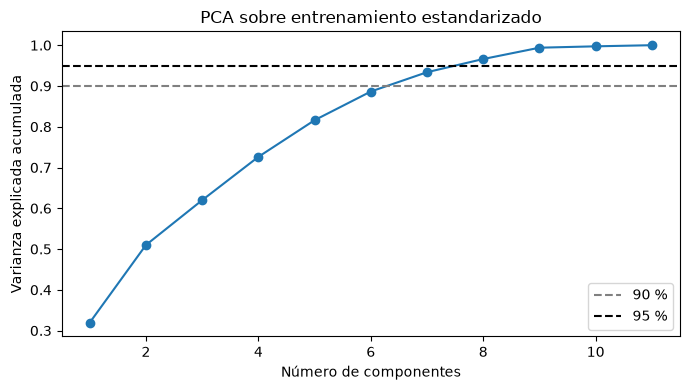

Componentes para 90 %: 7
Componentes para 95 %: 8


In [7]:
X_escalado = StandardScaler().fit_transform(X_train)

pca_descriptivo = PCA(svd_solver="full")
pca_descriptivo.fit(X_escalado)

varianza_acumulada = np.cumsum(
    pca_descriptivo.explained_variance_ratio_
)

plt.figure(figsize=(7, 4))
plt.plot(
    range(1, len(varianza_acumulada) + 1),
    varianza_acumulada,
    marker="o"
)
plt.axhline(0.90, color="gray", linestyle="--", label="90 %")
plt.axhline(0.95, color="black", linestyle="--", label="95 %")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("PCA sobre entrenamiento estandarizado")
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + "02_pca_varianza.png", dpi=150)
plt.show()

print(
    "Componentes para 90 %:",
    int(np.argmax(varianza_acumulada >= 0.90)) + 1
)
print(
    "Componentes para 95 %:",
    int(np.argmax(varianza_acumulada >= 0.95)) + 1
)

En el ajuste descriptivo necesitamos siete componentes para explicar el 90 % de la varianza y ocho para el 95 %. Estas proporciones describen la variabilidad de las entradas, no la exactitud de las predicciones.

## ¿PCA mejora la predicción?

Evaluamos PCA con 90 % y 95 % de varianza, siempre precedido de StandardScaler.

Comparamos estas alternativas con las once entradas sin PCA. La reducción
solo resulta útil para predecir si sus resultados lo justifican; explicar mucha
varianza no garantiza detectar mejor el abandono.

In [8]:
rows_pca = []

for proporcion in [0.90, 0.95]:
    nombre = "PCA " + str(int(proporcion * 100)) + "%"

    pipeline = crear_pipeline(
        "StandardScaler",
        PCA(n_components=proporcion, svd_solver="full")
    )

    pipelines[nombre] = pipeline

    fila = evaluar_cv(
        pipeline, X_train, y_train,
        particiones_cv, metricas, nombre
    )

    rows_pca.append(fila)

# Incluimos StandardScaler sin PCA para comparar en la misma escala.
referencia_pca = tabla_escalado.loc[
    tabla_escalado["Nombre"] == "StandardScaler"
]

tabla_pca = pd.concat(
    [referencia_pca, pd.DataFrame(rows_pca)],
    ignore_index=True
)

tabla_pca.to_csv(
    RUTA_RESULTADOS + "02_comparacion_pca.csv",
    index=False
)

tabla_pca.round(3)

,Nombre,F1,F1_std,Precision,Recall
0,StandardScaler,0.597,0.063,0.454,0.880
1,PCA 90%,0.573,0.057,0.435,0.852
2,PCA 95%,0.572,0.054,0.432,0.852


PCA al 90 % obtuvo F1 de 0,573 y al 95 %, 0,572, frente a 0,597 con StandardScaler sin PCA. Ninguna reducción mejoró el F1 promedio del modelo de referencia.

## Selección de variables con ANOVA

A diferencia de PCA, la selección conserva columnas originales.

SelectKBest con ANOVA ordena las entradas según diferencias entre las clases.
Probamos conservar desde una hasta diez variables y comparamos con las once.

El selector aprende dentro de cada partición. Las columnas seleccionadas pueden
cambiar entre particiones. ANOVA estudia cada entrada por separado y puede
conservar variables redundantes o ignorar interacciones útiles.

In [9]:
rows_seleccion = []

for k in range(1, X_train.shape[1]):
    nombre = "ANOVA k=" + str(k)

    pipeline = crear_pipeline(
        escalador_elegido,
        SelectKBest(score_func=f_classif, k=k)
    )

    pipelines[nombre] = pipeline

    fila = evaluar_cv(
        pipeline, X_train, y_train,
        particiones_cv, metricas, nombre
    )

    rows_seleccion.append(fila)
    print(nombre, "-> F1:", round(fila["F1"], 3))

tabla_seleccion = pd.DataFrame(rows_seleccion)

referencia_seleccion = tabla_escalado.loc[
    tabla_escalado["Nombre"] == escalador_elegido
]

tabla_seleccion = pd.concat(
    [referencia_seleccion, tabla_seleccion],
    ignore_index=True
)

tabla_seleccion.to_csv(
    RUTA_RESULTADOS + "02_comparacion_seleccion.csv", index=False
)
tabla_seleccion.round(3)

ANOVA k=1 -> F1: 0.548
ANOVA k=2 -> F1: 0.533


ANOVA k=3 -> F1: 0.548
ANOVA k=4 -> F1: 0.552


ANOVA k=5 -> F1: 0.551
ANOVA k=6 -> F1: 0.567


ANOVA k=7 -> F1: 0.559
ANOVA k=8 -> F1: 0.559


ANOVA k=9 -> F1: 0.567
ANOVA k=10 -> F1: 0.573


,Nombre,F1,F1_std,Precision,Recall
0,StandardScaler,0.597,0.063,0.454,0.880
1,ANOVA k=1,0.548,0.091,0.834,0.413
2,ANOVA k=2,0.533,0.057,0.403,0.796
3,ANOVA k=3,0.548,0.062,0.418,0.804
4,ANOVA k=4,0.552,0.061,0.421,0.812
5,ANOVA k=5,0.551,0.055,0.416,0.827
6,ANOVA k=6,0.567,0.068,0.429,0.845
7,ANOVA k=7,0.559,0.064,0.422,0.837
8,ANOVA k=8,0.559,0.071,0.423,0.837
9,ANOVA k=9,0.567,0.065,0.431,0.840


El mejor subconjunto ANOVA retiene diez variables, con F1 de 0,573. Conservar las once dio 0,597. La opción de una variable tiene precisión de 0,834 y recall de 0,413: sus alertas son más precisas, pero deja sin detectar más abandonos.

## Comparación general

Reunimos las alternativas sin reducción, con PCA y con selección de variables.
Tomamos el mayor F1 promedio como criterio operativo; en empates exactos
conservamos la primera alternativa de la tabla.

Como utilizamos estas mismas particiones para elegir, el resultado ganador
puede ser optimista. Es una comparación de desarrollo, no la evaluación final.

La preparación elegida es una referencia inicial basada en regresión logística;
no necesariamente será la mejor para todos los clasificadores.

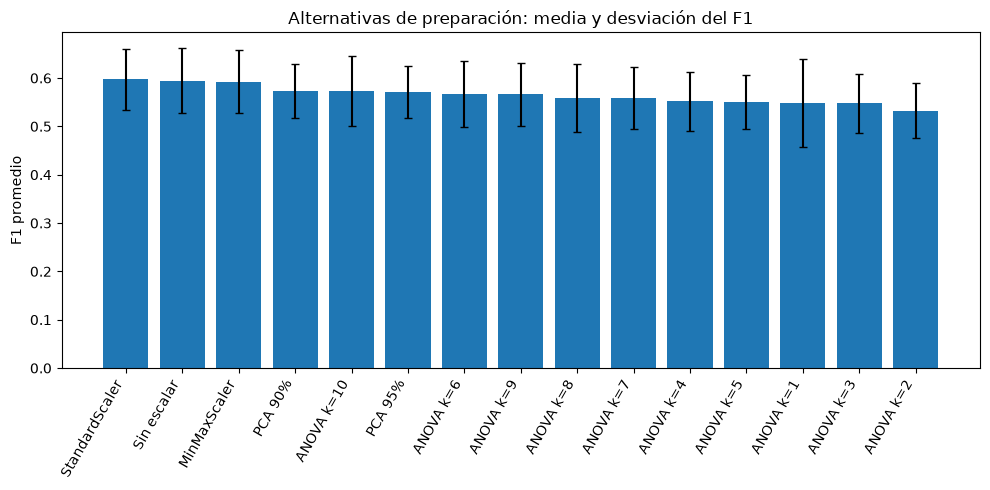

Alternativa con mayor F1: StandardScaler


,Nombre,F1,F1_std,Precision,Recall
1,StandardScaler,0.597,0.063,0.454,0.880
0,Sin escalar,0.595,0.067,0.450,0.886
2,MinMaxScaler,0.592,0.065,0.452,0.870
3,PCA 90%,0.573,0.057,0.435,0.852
14,ANOVA k=10,0.573,0.073,0.437,0.845
4,PCA 95%,0.572,0.054,0.432,0.852
10,ANOVA k=6,0.567,0.068,0.429,0.845
13,ANOVA k=9,0.567,0.065,0.431,0.840
12,ANOVA k=8,0.559,0.071,0.423,0.837
11,ANOVA k=7,0.559,0.064,0.422,0.837


In [10]:
comparacion = pd.concat(
    [
        tabla_escalado,
        pd.DataFrame(rows_pca),
        pd.DataFrame(rows_seleccion)
    ],
    ignore_index=True
)

nombre_elegido = comparacion.loc[
    comparacion["F1"].idxmax(), "Nombre"
]

comparacion.to_csv(
    RUTA_RESULTADOS + "comparacion_rasgos.csv",
    index=False
)

tabla_ordenada = comparacion.sort_values(
    "F1", ascending=False, kind="stable"
)

plt.figure(figsize=(10, 5))
plt.bar(
    tabla_ordenada["Nombre"],
    tabla_ordenada["F1"],
    yerr=tabla_ordenada["F1_std"],
    capsize=3
)
plt.xticks(rotation=60, ha="right")
plt.ylabel("F1 promedio")
plt.title("Alternativas de preparación: media y desviación del F1")
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + "02_comparacion_rasgos.png", dpi=150)
plt.show()

print("Alternativa con mayor F1:", nombre_elegido)
tabla_ordenada.round(3)

Entre las 15 alternativas elegimos StandardScaler sin reducción, con F1 de 0,597 y desviación de 0,063, precisión de 0,454 y recall de 0,880. Son promedios entre particiones utilizados para seleccionar; no son métricas finales sobre prueba.

## Guardar la preparación elegida

Guardamos una plantilla sin ajustar del preprocesamiento elegido.
El notebook 03 debe colocarla dentro de cada pipeline para que vuelva a aprender
solamente con el entrenamiento de cada partición.

También ajustamos una copia con entrenamiento completo para describir qué
columnas o cuántos componentes produce. Este ajuste es descriptivo y no se usa
para obtener las métricas anteriores.
Para usar la plantilla con imblearn, concatenamos sus pasos con los del nuevo
clasificador en un único pipeline. No colocamos otro Pipeline como un paso intermedio,
porque imblearn no permite ese anidamiento.

In [11]:
pipeline_elegido = pipelines[nombre_elegido]

preprocesamiento = clone(pipeline_elegido[:-1])

# Esta copia sirve solamente para describir el resultado sobre todo train.
preprocesamiento_descriptivo = clone(preprocesamiento)
preprocesamiento_descriptivo.fit(X_train, y_train)

transformador = preprocesamiento_descriptivo.named_steps["transformador"]

if isinstance(transformador, SelectKBest):
    rasgos_descriptivos = X_train.columns[
        transformador.get_support()
    ].tolist()

    print("Columnas seleccionadas al ajustar con todo train:")
    print(rasgos_descriptivos)

elif isinstance(transformador, PCA):
    print(
        "Componentes al ajustar con todo train:",
        transformador.n_components_
    )

else:
    print("Se conservan las once entradas.")

decisiones = {
    "alternativa": nombre_elegido,
    "columnas_entrada": list(X_train.columns),
    "preprocesamiento": preprocesamiento,
    "modelo_referencia": "RegresionLogisticaBalanced",
    "metrica_principal": "f1",
    "validacion": "StratifiedGroupKFold",
    "n_splits": 10,
    "random_state": 42
}


# Registramos las entradas concretas de esta comparación.
huellas = {}
for nombre_archivo in ["train.csv", "grupos_train.csv", "particion_01.json"]:
    with open(RUTA_DATOS + nombre_archivo, "rb") as archivo:
        huellas[nombre_archivo] = hashlib.sha256(archivo.read()).hexdigest()

decisiones["sha256_entradas"] = huellas
decisiones["metodos_evaluados"] = ["Sin reducción", "PCA", "ANOVA"]
decisiones["parametros_modelo_referencia"] = pipeline_elegido.named_steps["modelo"].get_params()
decisiones["uso_notebook_03"] = "Clonar y concatenar los pasos del preprocesamiento en el pipeline del clasificador; no anidar un Pipeline como paso de imblearn."

joblib.dump(
    decisiones,
    RUTA_MODELOS + "decisiones_preprocesamiento.joblib"
)

print("Decisiones guardadas.")
# Verificamos que el archivo contiene una plantilla sin entrenar.
decisiones_cargadas = joblib.load(
    RUTA_MODELOS + "decisiones_preprocesamiento.joblib"
)
plantilla = decisiones_cargadas["preprocesamiento"]
for nombre_paso, paso in plantilla.steps:
    if not isinstance(paso, str):
        assert not hasattr(paso, "n_features_in_")

# imblearn exige pasos planos: comprobamos la integración con un clasificador.
pasos = list(clone(plantilla).steps)
pasos.append(("modelo", clone(pipeline_elegido.named_steps["modelo"])))
pipeline_verificacion = Pipeline(pasos)
indices_ajuste = particiones_cv[0][0]
pipeline_verificacion.fit(
    X_train.iloc[indices_ajuste], y_train.iloc[indices_ajuste]
)
assert pipeline_verificacion.n_features_in_ == X_train.shape[1]
print("Plantilla sin ajustar e integración con el siguiente pipeline verificadas.")

Se conservan las once entradas.
Decisiones guardadas.
Plantilla sin ajustar e integración con el siguiente pipeline verificadas.


La decisión guardada conserva las once entradas y usa StandardScaler. La plantilla está sin ajustar y comprobamos que sus pasos pueden integrarse en el pipeline del siguiente notebook.

## Conclusiones

Evaluamos 15 alternativas con regresión logística balanceada y las mismas diez
particiones por grupos, usando las 2.511 filas de entrenamiento. No consultamos prueba.

StandardScaler obtuvo el mayor F1 promedio: 0,597, frente a 0,595 sin escalar y
0,592 con MinMaxScaler. Elegimos StandardScaler por la regla de mayor F1; la
diferencia es pequeña frente a la variación entre particiones y no demuestra
superioridad concluyente.

PCA necesitó siete componentes para el 90 % de varianza y ocho para el 95 % en el
ajuste descriptivo. Sus F1 fueron 0,573 y 0,572. No elegimos PCA: reducir dimensiones
no mejoró el criterio predictivo en estas comparaciones.

Entre los subconjuntos ANOVA, el mayor F1 fue 0,573 con diez variables. Ningún
subconjunto superó las once entradas, así que conservamos todas. Esto no significa
que todas sean indispensables: edad y grupo de edad siguen siendo redundantes,
y ANOVA no examina todos los subconjuntos ni las interacciones.

La alternativa elegida obtuvo precisión media de 0,454, recall de 0,880 y desviación
del F1 de 0,063. Detecta una proporción alta de abandonos, pero más de la mitad
de sus alertas son falsas, aproximadamente, según los promedios de validación.

Guardamos StandardScaler sin reducción en una plantilla sin ajustar. El notebook 03
deberá reajustarla dentro de cada partición al comparar modelos. La ponderación
balanceada corresponde al modelo de referencia de este notebook; todavía no
hemos elegido el balanceo ni el clasificador final.

Esta versión simplificada compara un solo modelo de referencia y selección ANOVA.
No incluye SVM para escaladores ni otros selectores de la versión de minas.
El mejor F1 es una medida de desarrollo utilizada para elegir opciones, no una
estimación independiente del rendimiento final ni un porcentaje de aciertos.